# Intrinsic Value and Discounted Cash Flow Explained

*Analyst Desk · The Analytical Investor · Year 1, Month 5*

**Read the article:** [Intrinsic Value and Discounted Cash Flow Explained](https://analytical-investor.blog/?p=1006)

Checks every number in the article: present values, the example business's intrinsic value, and how much it moves when the discount rate or terminal growth changes.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Present value of 1 million

In [2]:
for years in (1, 10):
    print(f"1,000,000 in {years:>2} year(s) at 10%: {1e6 / 1.1**years:,.0f} today")

1,000,000 in  1 year(s) at 10%: 909,091 today
1,000,000 in 10 year(s) at 10%: 385,543 today


## The article's example business
100 of free cash flow, 8% growth for ten years, 3% forever.

In [3]:
def dcf(fcf0, g, n, g_term, r):
    pv, f = 0.0, fcf0
    for t in range(1, n + 1):
        f *= 1 + g
        pv += f / (1 + r) ** t
    pv_tv = f * (1 + g_term) / (r - g_term) / (1 + r) ** n
    return pv + pv_tv, pv_tv / (pv + pv_tv)

base, share = dcf(100, 0.08, 10, 0.03, 0.12)
for label, (r, gt) in {"Base (12%, 3%)": (0.12, 0.03), "Discount rate 10%": (0.10, 0.03),
                       "Terminal growth 4%": (0.12, 0.04)}.items():
    v, s = dcf(100, 0.08, 10, gt, r)
    print(f"{label:<20} value {v:,.0f}  ({v / base - 1:+.0%} vs base)  terminal share {s:.0%}")

Base (12%, 3%)       value 1,619  (+0% vs base)  terminal share 49%
Discount rate 10%    value 2,130  (+32% vs base)  terminal share 57%
Terminal growth 4%   value 1,727  (+7% vs base)  terminal share 52%


## How the terminal share grows with the discount rate

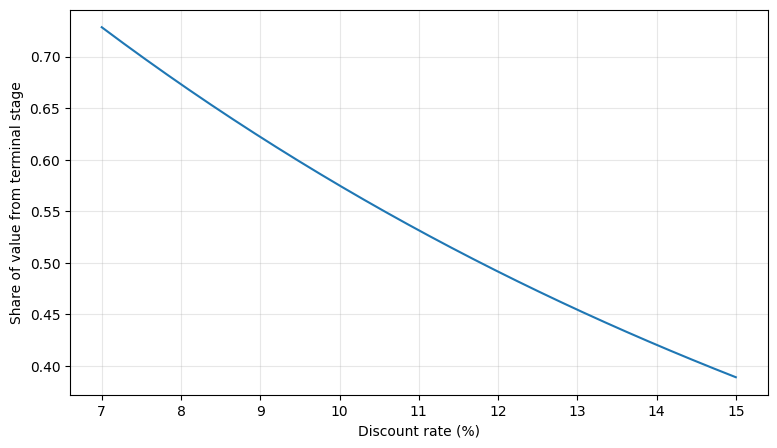

In [4]:
rates = np.linspace(0.07, 0.15, 30)
plt.plot(rates * 100, [dcf(100, 0.08, 10, 0.03, r)[1] for r in rates])
plt.xlabel("Discount rate (%)"); plt.ylabel("Share of value from terminal stage"); plt.show()